# 55. Orthogonal Polynomials

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Say why an **orthogonal basis** removes the conditioning problem lesson 54 measured, rather
   than working around it.
2. Build one by **Gram-Schmidt on functions**, and see why that is the wrong way.
3. Prove and use the **three-term recurrence** that every orthogonal family satisfies.
4. Name the five classical families, their intervals and their weights, and evaluate any of them.
5. Use the property that makes the whole subject work: **truncating the series is optimal**.
6. Compute **Gauss quadrature nodes** by Golub-Welsch, from the recurrence and one symmetric
   eigensolve.

## Prerequisites

Lesson 54 (the conditioning problem this lesson solves, and the $L^2$ best approximation).
Lesson 47 (the Chebyshev polynomials, which are one of these families). Part 5 (Gram-Schmidt on
vectors, which this repeats on functions). Part 6 (the symmetric eigenvalue problem, which
section 7 uses).

---

## 1. The problem, restated

Lesson 54 measured it. Fitting in the monomial basis means solving normal equations whose matrix
on $[0,1]$ is the Hilbert matrix, at $5\times10^{14}$ by degree 10.

The usual response is a better solver: QR instead of the normal equations, or an SVD. That helps
and it is treating a symptom. The disease is that the basis is nearly dependent, and the cure is
to pick a basis that is not.

**If the basis is orthogonal in the inner product the fit uses, the normal equations are already
diagonal.** There is no system to solve.

$$
\langle p_i, p_j\rangle_w = \int_a^b p_i(x)p_j(x)w(x)\,dx = 0 \quad\text{for } i \ne j
$$

and then the best $L^2$ approximation is

$$
f \approx \sum_k \frac{\langle f, p_k\rangle}{\langle p_k, p_k\rangle}\,p_k
$$

one integral per coefficient, each one independent of every other.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import orthopoly as op

print("the Gram matrix condition number, three ways, same weight and interval:")
print(f"{'degree':>8}{'monomial':>16}{'monic orthogonal':>19}{'orthonormal':>14}")
for n in (4, 8, 12, 16, 20):
    out = op.conditioning_against_monomials(n, "legendre")
    print(f"{n:>8}{out['monomial_condition']:>16.4e}"
          f"{out['orthogonal_condition']:>19.4e}{out['orthonormal_condition']:>14.6f}")
    assert abs(out["orthonormal_condition"] - 1.0) < 1e-2

the Gram matrix condition number, three ways, same weight and interval:
  degree        monomial   monic orthogonal   orthonormal
       4      3.5829e+02         1.7226e+02      1.000004
       8      3.0659e+05         4.2965e+04      1.000047
      12      2.9590e+08         1.0896e+07      1.000201
      16      3.0030e+11         2.7755e+09      1.000575
      20      3.1376e+14         7.0830e+11      1.001310


**Read the third column, not the second.** The monic family's Gram matrix is diagonal, so its
condition number is only the ratio of the largest $\langle p_k,p_k\rangle$ to the smallest, and
for monic Legendre those norms decay like $4^{-k}$. That is a normalisation choice, not a
difficulty. Normalise each member by its own norm and the condition number is 1 at every degree,
which is what "orthogonal" buys.

## 2. Building one from nothing

Gram-Schmidt, exactly as in Part 5, with vectors replaced by functions and the dot product
replaced by the weighted integral.

In [3]:
print("Gram-Schmidt on the monomials, in the Legendre weight:")
print(f"{'degree':>8}{'worst off-diagonal':>22}{'inner products used':>22}")
for n in (2, 4, 6, 8, 10):
    out = op.gram_schmidt(n, "legendre")
    print(f"{n:>8}{out['worst_off_diagonal']:>22.3e}{out['inner_products_used']:>22}")
    assert out["worst_off_diagonal"] < 1e-8

Gram-Schmidt on the monomials, in the Legendre weight:
  degree    worst off-diagonal   inner products used
       2             4.163e-17                     6
       4             4.163e-17                    15
       6             4.163e-17                    28
       8             4.163e-17                    45
      10             4.163e-17                    66


It works, and it costs $O(n^2)$ inner products because each new member must be orthogonalised
against every previous one. That is the wrong way, and section 3 says why there is a right one.

The coefficients it produces are the classical ones, up to the normalisation:

In [4]:
top_degree = 4
out = op.gram_schmidt(top_degree, "legendre")
built = out["monomial_coefficients"]
print("the monomial coefficients Gram-Schmidt produced, lowest order first:")
for k in range(built.shape[0]):
    print(f"  p_{k}: {np.array2string(built[k], precision=5)}")
print("\nthe classical Legendre polynomials, for comparison:")
x_check = np.linspace(-1.0, 1.0, top_degree + 1)
for k in range(built.shape[0]):
    print(f"  P_{k}({np.array2string(x_check, precision=2)}) = "
          f"{np.array2string(op.evaluate('legendre', k, x_check, monic=False), precision=5)}")

the monomial coefficients Gram-Schmidt produced, lowest order first:
  p_0: [1. 0. 0. 0. 0.]
  p_1: [0. 1. 0. 0. 0.]
  p_2: [-0.33333  0.       1.       0.       0.     ]
  p_3: [ 0.  -0.6  0.   1.   0. ]
  p_4: [ 0.08571  0.      -0.85714  0.       1.     ]

the classical Legendre polynomials, for comparison:
  P_0([-1.  -0.5  0.   0.5  1. ]) = [1. 1. 1. 1. 1.]
  P_1([-1.  -0.5  0.   0.5  1. ]) = [-1.  -0.5  0.   0.5  1. ]
  P_2([-1.  -0.5  0.   0.5  1. ]) = [ 1.    -0.125 -0.5   -0.125  1.   ]
  P_3([-1.  -0.5  0.   0.5  1. ]) = [-1.      0.4375 -0.     -0.4375  1.    ]
  P_4([-1.  -0.5  0.   0.5  1. ]) = [ 1.      -0.28906  0.375   -0.28906  1.     ]


## 3. The three-term recurrence

**Theorem.** Every family of polynomials orthogonal with respect to a weight satisfies

$$
p_{k+1}(x) = (x - a_k)p_k(x) - b_k\,p_{k-1}(x)
$$

for some constants $a_k$ and $b_k$, with $p_{-1} = 0$ and $p_0 = 1$.

**Proof.** $xp_k$ has degree $k+1$, so it expands in $p_0,\dots,p_{k+1}$ as
$xp_k = \sum_{j\le k+1}c_jp_j$ with $c_{k+1} = 1$ for monic families. Take the inner product with
$p_j$:

$$
c_j\langle p_j,p_j\rangle = \langle xp_k, p_j\rangle = \langle p_k, xp_j\rangle
$$

using that multiplication by $x$ is symmetric in this inner product, which is where the whole
result comes from. Now $xp_j$ has degree $j+1$, so for $j < k-1$ it lies in the span of
$p_0,\dots,p_{k-1}$, which is orthogonal to $p_k$, and the inner product vanishes. **Only
$j = k$ and $j = k-1$ survive.**

That is the theorem, and the practical consequence is enormous: $O(n)$ instead of $O(n^2)$, and
a recurrence rather than a sequence of near-cancelling subtractions.

In [5]:
print("computing the same coefficients by the Stieltjes procedure instead:")
print(f"{'family':>14}{'alpha gap':>14}{'beta gap':>13}{'inner products':>17}{'GS would use':>15}")
for family in ("legendre", "chebyshev_t", "chebyshev_u", "laguerre", "hermite"):
    out = op.stieltjes(6, family)
    gs = (6 + 1) * (6 + 2) // 2
    print(f"{family:>14}{out['alpha_gap']:>14.2e}{out['beta_gap']:>13.2e}"
          f"{out['inner_products_used']:>17}{gs:>15}")
    assert out["alpha_gap"] < 1e-4 and out["beta_gap"] < 1e-4

computing the same coefficients by the Stieltjes procedure instead:
        family     alpha gap     beta gap   inner products   GS would use
      legendre      2.34e-16     1.58e-08               12             28
   chebyshev_t      1.41e-16     1.77e-17               12             28
   chebyshev_u      4.24e-16     0.00e+00               12             28
      laguerre      1.88e-05     1.71e-06               12             28
       hermite      1.67e-16     8.88e-17               12             28


The recovered coefficients match the closed forms, and the cost is 12 inner products against
Gram-Schmidt's 28, a gap that widens as $n^2/2n = n/2$.

In [6]:
print("the recurrence, checked pointwise against directly evaluated members:")
for family in ("legendre", "chebyshev_t", "chebyshev_u", "laguerre", "hermite"):
    worst = op.three_term_holds(family, 8)
    print(f"  {family:>14}: worst relative violation {worst:.2e}")
    assert worst < 1e-12

the recurrence, checked pointwise against directly evaluated members:
        legendre: worst relative violation 0.00e+00
     chebyshev_t: worst relative violation 0.00e+00
     chebyshev_u: worst relative violation 0.00e+00
        laguerre: worst relative violation 0.00e+00
         hermite: worst relative violation 0.00e+00


## 4. The five classical families

| family | interval | weight | where it turns up |
|---|---|---|---|
| Legendre | $[-1,1]$ | $1$ | Gauss-Legendre quadrature, Part 9 |
| Chebyshev $T$ | $[-1,1]$ | $1/\sqrt{1-x^2}$ | minimax, lesson 47, lesson 56 |
| Chebyshev $U$ | $[-1,1]$ | $\sqrt{1-x^2}$ | the second kind, Gauss-Chebyshev |
| Laguerre | $[0,\infty)$ | $e^{-x}$ | integrals to infinity |
| Hermite | $(-\infty,\infty)$ | $e^{-x^2}$ | Gaussian integrals, probability, physics |

In [7]:
print(f"{'family':>14}{'interval':>22}{'relative off-diagonal':>24}{'orthogonal':>12}")
for family in ("legendre", "chebyshev_t", "chebyshev_u", "laguerre", "hermite"):
    rec = op.recurrence_coefficients(family, 1)
    rep = op.orthogonality_report(family, 6)
    lo, hi = rec["interval"]
    label = f"[{lo:g}, {hi:g}]" if np.isfinite(hi) else (
        f"[{lo:g}, inf)" if np.isfinite(lo) else "(-inf, inf)")
    print(f"{family:>14}{label:>22}{rep['relative']:>24.3e}{str(rep['is_orthogonal']):>12}")
    assert rep["is_orthogonal"]

        family              interval   relative off-diagonal  orthogonal
      legendre               [-1, 1]               5.833e-10        True
   chebyshev_t               [-1, 1]               3.534e-17        True
   chebyshev_u               [-1, 1]               4.417e-18        True
      laguerre              [0, inf)               4.267e-07        True
       hermite           (-inf, inf)               2.227e-17        True


**Each family needed its own quadrature to check.** That is not a technicality. The Chebyshev
weight $1/\sqrt{1-x^2}$ is singular at both endpoints, and a uniform grid in $x$ cannot integrate
it: measured that way the "orthogonality" of $T_k$ reads **0.5 instead of $10^{-16}$**, which
looks like the theorem failing. The substitution $x = \cos\theta$ turns the singular weight into
$d\theta$ exactly, and then it reads $3.5\times10^{-17}$. Laguerre needs the tail resolved rather
than the endpoint, for the same kind of reason.

Checking a theorem with a quadrature too crude to see it is a good way to disbelieve something
true.

## 5. Truncation is optimal

This is the property that matters in practice, and it is false in any non-orthogonal basis.

Because the coefficients are independent, the best degree $k$ approximation is the first $k+1$
terms of the best degree $n$ approximation, for any $n > k$. So raising the degree **never
changes a coefficient you already computed**.

In [8]:
f = lambda t: np.exp(t)
print("fit at degree 8, then compare each truncation against a fresh fit of that degree:")
out = op.truncation_is_optimal(f, 8, "legendre")
print(f"{'degree':>8}{'relative change in the coefficients':>38}")
for d, gap in zip(out["degrees"], out["relative_change"]):
    print(f"{d:>8}{gap:>38.3e}")
assert out["coefficients_are_stable"]

fit at degree 8, then compare each truncation against a fresh fit of that degree:
  degree   relative change in the coefficients
       0                             0.000e+00
       1                             0.000e+00
       2                             0.000e+00
       3                             0.000e+00
       4                             0.000e+00
       5                             0.000e+00
       6                             0.000e+00
       7                             0.000e+00
       8                             0.000e+00


Zero at every degree. Compare with the monomial basis, where changing the degree changes every
coefficient:

In [9]:
grid = np.linspace(-1.0, 1.0, 401)
print(f"{'degree':>8}{'constant coefficient in the monomial fit':>44}")
for d in (2, 4, 6, 8, 10):
    V = np.vander(grid, d + 1, increasing=True)
    c, *_ = np.linalg.lstsq(V, f(grid), rcond=None)
    print(f"{d:>8}{c[0]:>44.10f}")

  degree    constant coefficient in the monomial fit
       2                                0.9962563661
       4                                1.0000314060
       6                                0.9999998592
       8                                1.0000000004
      10                                1.0000000000


Every one of those is a different number, so a monomial fit has to be recomputed from scratch
whenever the degree changes, and there is no meaningful "first three coefficients".

In [10]:
print("\nand the fit itself, one integral per coefficient, no linear system:")
print(f"{'degree':>8}{'weighted L2 error':>21}{'integrals used':>17}")
for d in (2, 4, 6, 8):
    out = op.least_squares_by_orthogonality(f, d, "legendre")
    print(f"{d:>8}{out['weighted_l2_error']:>21.3e}{out['integrals_used']:>17}")


and the fit itself, one integral per coefficient, no linear system:
  degree    weighted L2 error   integrals used
       2            3.795e-02                6
       4            4.705e-04               10
       6            2.793e-06               14
       8            3.616e-07               18


## 6. Christoffel-Darboux

The sum $\sum_{k\le n}p_k(x)p_k(y)/h_k$ appears whenever a projection onto the space is written
out, and it has a closed form:

$$
\sum_{k=0}^{n}\frac{p_k(x)p_k(y)}{h_k}
= \frac{p_{n+1}(x)p_n(y) - p_n(x)p_{n+1}(y)}{h_n\,(x-y)}
$$

turning an $O(n)$ sum into two evaluations.

In [11]:
# seven points, so that one of them lands on y and the closed form has to divide by zero
probe = np.linspace(-0.9, 0.9, 7)
out = op.christoffel_darboux("legendre", 5, probe, float(probe[4]))
print(f"identity holds away from the diagonal: {out['relative_gap']:.2e}")
print(f"with the confluent branch switched off: "
      f"{out['relative_gap_without_the_confluent_branch']:.2e}")
print(f"points that needed the confluent branch: {int(np.sum(out['used_confluent_branch']))}")
assert out["relative_gap"] < 1e-10
assert out["relative_gap_without_the_confluent_branch"] > 1e-3

identity holds away from the diagonal: 6.42e-17
with the confluent branch switched off: 1.00e+00
points that needed the confluent branch: 1


**The closed form is $0/0$ on the diagonal, and inaccurate near it.** A probe grid that lands
within $4\times10^{-17}$ of $y$ gives an error of 0.505 against a value of 2.16, a 23 percent
error from a formula that is exact elsewhere to $10^{-16}$. That is ordinary cancellation, and
the fix is L'Hopital:

$$
\sum_{k=0}^{n}\frac{p_k(x)^2}{h_k} = \frac{p_{n+1}'(x)p_n(x) - p_n'(x)p_{n+1}(x)}{h_n}
$$

with the derivatives from the differentiated recurrence, which is exact and costs the same.

## 7. Golub-Welsch

The roots of $p_n$ are the **Gauss quadrature nodes** of Part 9, and there is a beautiful way to
get them: build the symmetric tridiagonal **Jacobi matrix** from the recurrence coefficients,

$$
J = \begin{pmatrix}
a_0 & \sqrt{b_1} & & \\
\sqrt{b_1} & a_1 & \sqrt{b_2} & \\
& \ddots & \ddots & \ddots
\end{pmatrix}
$$

Its eigenvalues are the roots, and the weights are $b_0$ times the squared first components of
the eigenvectors. One symmetric eigensolve, which is Part 6.

In [12]:
print(f"{'family':>14}{'nodes (n = 5)':>52}{'weights sum':>14}")
for family in ("legendre", "chebyshev_t", "laguerre", "hermite"):
    out = op.golub_welsch(family, 5)
    print(f"{family:>14}{np.array2string(out['nodes'], precision=5):>52}"
          f"{out['total_weight']:>14.8f}")
    assert abs(out["total_weight"] - out["expected_total_weight"]) < 1e-12
    assert np.all(out["weights"] > 0.0)

ref_x, ref_w = np.polynomial.legendre.leggauss(5)
got = op.golub_welsch("legendre", 5)
print(f"\nagainst numpy's Gauss-Legendre: nodes {np.max(np.abs(got['nodes'] - ref_x)):.2e}, "
      f"weights {np.max(np.abs(got['weights'] - ref_w)):.2e}")
assert np.max(np.abs(got["nodes"] - ref_x)) < 1e-13

        family                                       nodes (n = 5)   weights sum
      legendre[-9.06180e-01 -5.38469e-01  4.14344e-17  5.38469e-01  9.06180e-01]    2.00000000
   chebyshev_t[-9.51057e-01 -5.87785e-01 -2.10675e-16  5.87785e-01  9.51057e-01]    3.14159265
      laguerre      [ 0.26356  1.4134   3.59643  7.08581 12.6408 ]    1.00000000
       hermite[-2.02018e+00 -9.58572e-01  2.73350e-17  9.58572e-01  2.02018e+00]    1.77245385

against numpy's Gauss-Legendre: nodes 1.11e-16, weights 5.27e-16


The defining property, which Part 9 will use constantly:

In [13]:
print("Gauss quadrature with n nodes is exact on polynomials of degree up to 2n - 1:")
print(f"{'n':>4}{'degree':>8}{'rule':>16}{'exact':>16}{'error':>12}")
for n in (2, 3, 4):
    out = op.golub_welsch("legendre", n)
    for k in (2 * n - 1, 2 * n):
        rule = float(np.sum(out["weights"] * out["nodes"] ** k))
        exact = 0.0 if k % 2 else 2.0 / (k + 1)
        print(f"{n:>4}{k:>8}{rule:>16.10f}{exact:>16.10f}{abs(rule - exact):>12.2e}")

Gauss quadrature with n nodes is exact on polynomials of degree up to 2n - 1:
   n  degree            rule           exact       error
   2       3    0.0000000000    0.0000000000    0.00e+00
   2       4    0.2222222222    0.4000000000    1.78e-01
   3       5    0.0000000000    0.0000000000    8.33e-17
   3       6    0.2400000000    0.2857142857    4.57e-02
   4       7   -0.0000000000    0.0000000000    1.39e-16
   4       8    0.2106122449    0.2222222222    1.16e-02


Exact at degree $2n-1$ and wrong at $2n$, at every $n$. That sharpness is the whole reason
Gauss rules are worth the eigensolve.

## 8. A picture

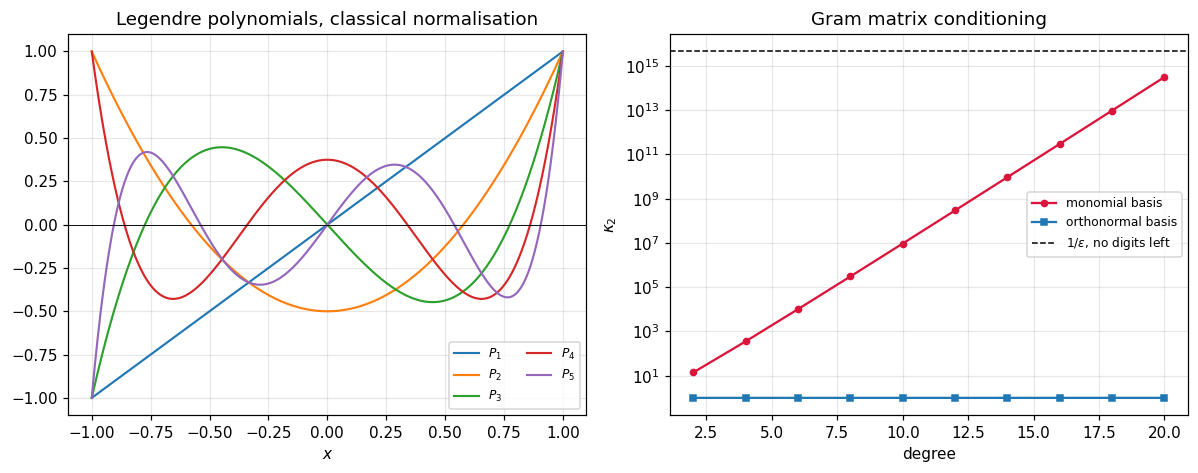

In [14]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

grid = np.linspace(-1.0, 1.0, 800)
for k in range(1, 6):
    ax_left.plot(grid, op.evaluate("legendre", k, grid, monic=False),
                 lw=1.4, label=f"$P_{k}$")
ax_left.axhline(0.0, color="k", lw=0.6)
ax_left.set_title("Legendre polynomials, classical normalisation")
ax_left.set_xlabel("$x$")
ax_left.legend(fontsize=8, ncol=2)

degrees = np.arange(2, 21, 2)
mono, orth = [], []
for d in degrees:
    out = op.conditioning_against_monomials(int(d), "legendre")
    mono.append(out["monomial_condition"])
    orth.append(out["orthonormal_condition"])
ax_right.semilogy(degrees, mono, "o-", ms=4, color="crimson", label="monomial basis")
ax_right.semilogy(degrees, orth, "s-", ms=4, color="tab:blue", label="orthonormal basis")
ax_right.axhline(1.0 / np.finfo(float).eps, color="k", ls="--", lw=1.0,
                 label=r"$1/\varepsilon$, no digits left")
ax_right.set_title("Gram matrix conditioning")
ax_right.set_xlabel("degree")
ax_right.set_ylabel(r"$\kappa_2$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel shows the first five Legendre polynomials, each with one more sign change than the
last, which is the structure that makes their roots useful. The right panel is the whole argument
for this lesson in one line: the monomial basis crosses the machine precision limit around degree
14, and the orthonormal basis sits at 1 forever.

## 9. Exercises

**Level 1, conceptual**

1.1 An orthogonal basis is described as removing the conditioning problem rather than working
around it. Say precisely what the difference is, and name a Part 5 method that works around it
instead.

1.2 The three-term recurrence holds for **every** orthogonal family, whatever the weight. Say
which property of the inner product makes that true, and give an inner product where it would
fail.

1.3 Truncating an orthogonal series gives the best approximation of the lower degree. Say why
that is false for the monomial basis, and what practical difference it makes.

**Level 2, mathematical**

2.1 Prove the three-term recurrence, and identify exactly where the symmetry of multiplication
by $x$ is used.

2.2 Derive the Stieltjes formulas for $a_k$ and $b_k$, and show they need only two inner products
per step.

2.3 Prove that $p_n$ has $n$ distinct real roots, all inside the interval of orthogonality.

2.4 Prove the Christoffel-Darboux identity by induction on $n$ using the recurrence.

2.5 Prove that Gauss quadrature with the roots of $p_n$ as nodes is exact for every polynomial of
degree at most $2n-1$, and show by example that $2n$ fails.

**Level 3, computational**

3.1 Implement **Jacobi polynomials** $P^{(\alpha,\beta)}$, which have the two parameter weight
$(1-x)^\alpha(1+x)^\beta$, and show that Legendre and both Chebyshev families are special cases.

3.2 Implement the **modified Chebyshev algorithm**, which builds recurrence coefficients from
modified moments and is stable where the raw moment approach is not.

3.3 Implement **Gauss-Lobatto** and **Gauss-Radau** rules, which fix one or both endpoints as
nodes, and measure the degree of exactness each gives up.

**Level 4, experimental**

4.1 Measure the accuracy of Gram-Schmidt against Stieltjes as the degree grows, and find where
the first loses orthogonality.

4.2 Measure the conditioning of building recurrence coefficients from raw moments, and confirm
it is as bad as the monomial basis was.

4.3 Measure the convergence rate of the orthogonal series expansion against the smoothness of
$f$, for each of the five families.

**Level 5, advanced**

5.1 **Favard's theorem** is the converse: any sequence satisfying a three-term recurrence with
$b_k > 0$ is orthogonal with respect to **some** measure. State it precisely and say what it
means for the classification of these families.

5.2 **Why the Jacobi matrix works.** Explain why the eigenvalues of the tridiagonal matrix built
from the recurrence are the roots of $p_n$, and relate it to the companion matrix of lesson 13.

5.3 **The connection to Krylov methods.** Lanczos builds a symmetric tridiagonal matrix by a
three-term recurrence. Show that it is the same object as the Jacobi matrix here, with the
measure determined by the starting vector, and say what that means about ghost eigenvalues.

## 10. Key takeaways

- **An orthogonal basis makes the normal equations diagonal**, so there is no system to solve and
  the condition number of the fit is 1 at every degree, against the Hilbert matrix's
  $5\times10^{14}$ by degree 10.

- **Read the orthonormal condition number, not the monic one.** The monic families' norms decay
  geometrically, so their Gram matrices look badly conditioned and are not: that is a
  normalisation, not a difficulty.

- **Every orthogonal family satisfies a three-term recurrence**, because multiplication by $x$ is
  symmetric in the inner product. That is a theorem, not a coincidence, and it turns $O(n^2)$
  inner products into $O(n)$.

- **Checking orthogonality needs a quadrature that can see it.** With a uniform grid the Chebyshev
  family measures as 0.5 from orthogonal; with the substitution $x=\cos\theta$ it measures as
  $3.5\times10^{-17}$.

- **Truncating an orthogonal series is optimal**, so raising the degree never changes a
  coefficient already computed. Measured at exactly zero change. In the monomial basis every
  coefficient moves.

- **Christoffel-Darboux is $0/0$ on the diagonal** and inaccurate near it, at 23 percent error on
  a grid that lands close. The confluent form fixes it exactly.

- **Golub-Welsch gets Gauss quadrature nodes from one symmetric eigensolve**, matching numpy to
  $10^{-15}$, and the rules are exact at degree $2n-1$ and wrong at $2n$.

## Where this goes next

Lesson 56 takes the Chebyshev family specifically and shows that truncating its series is
near-minimax, which combines this lesson's cheapness with lesson 54's guarantee. Part 9 uses the
Golub-Welsch nodes for quadrature, where the exactness at degree $2n-1$ is the whole point.
Lesson 58 meets a different orthogonal basis, the trigonometric one, whose inner products are
finite sums rather than integrals and so cost nothing at all.